# CSE 4260 — Computer Science in Medicine Sessional
## Week 2 Lab: Data Preprocessing — Missing Data, Encoding and Class Imbalance

**Student Name:** Roujatun Ferdus Rimi
**Student ID:** 0802310105101016

## Section 0 — Setup

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import SMOTE

import joblib
import os
from scipy.stats import chi2_contingency

sns.set_style("whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [17]:
COLUMN_NAMES = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv("UCI_heart_disease.csv", names=COLUMN_NAMES, na_values="?", header=0)

print(df.shape)
df.head()

(303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [18]:
CONTINUOUS_COLS  = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL_COLS = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

assert set(CONTINUOUS_COLS + CATEGORICAL_COLS) == set(df.columns) - {"target"}
print("Continuous :", CONTINUOUS_COLS)
print("Categorical:", CATEGORICAL_COLS)

Continuous : ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [19]:
df["cp"].unique()

array([1., 4., 3., 2.])

---
## Section 1 — Missing Value Audit

First we quantify how much data is missing, per feature, both as counts and percentages, and visualise
the missingness pattern.


      missing_count  missing_pct
ca                4         1.32
thal              2         0.66


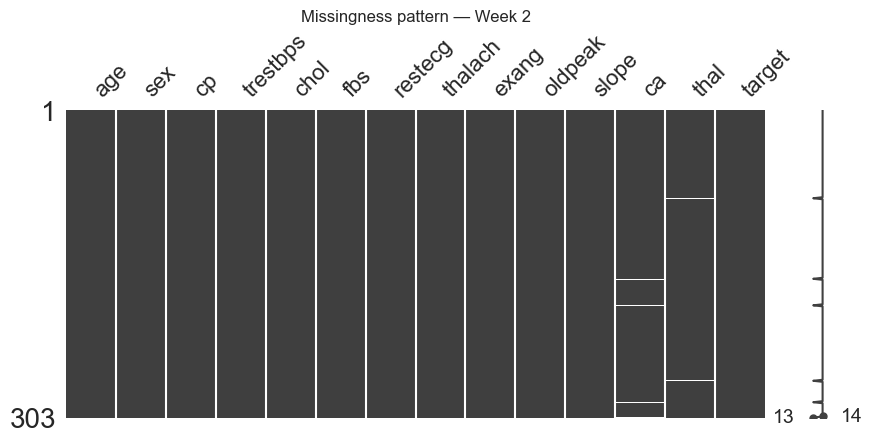

In [20]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
}).sort_values("missing_count", ascending=False)

print(missing_summary[missing_summary["missing_count"] > 0])

msno.matrix(df, figsize=(10, 4))
plt.title("Missingness pattern — Week 2")
plt.show()

**Does missingness relate to the outcome?**

For each feature that has missing values, we test whether **being missing** is associated with the
**target** class. This matters clinically: if sicker (or healthier) patients are systematically more
likely to have a missing measurement, that's informative — not random.

For each column in `cols_with_missing`, we create a binary "is missing" indicator, cross-tabulate it
against `target`, and run a chi-square test of independence.


In [21]:
cols_with_missing = missing_summary[missing_summary["missing_count"] > 0].index.tolist()
print("Columns with missing values:", cols_with_missing)

def test_missingness_vs_target(df, col, target_col="target"):
    indicator = df[col].isnull().astype(int)
    crosstab = pd.crosstab(indicator, df[target_col])
    print(crosstab)
    chi2, p_value, dof, expected = chi2_contingency(crosstab)
    return p_value

for col in cols_with_missing:
    p = test_missingness_vs_target(df, col)
    print(f"{col}: p-value = {p:.4f}")

Columns with missing values: ['ca', 'thal']
target    0    1
ca              
0       161  138
1         3    1
ca: p-value = 0.7351
target    0    1
thal            
0       163  138
1         1    1
thal: p-value = 1.0000


**Written Answer 1.1**

Based on the p-values above (use α = 0.05): for each column with missing values,
state whether missingness appears to be related to the outcome class, and briefly interpret what that
would mean clinically if it is (e.g., "patients who did not receive test X may differ systematically
from those who did").

**Your Answer:
For ca, the p-value is 0.7351, which is greater than α = 0.05. Therefore, there is no statistically significant evidence that ca missingness is related to the outcome class. Clinically, the available data do not show that patients with missing ca values are systematically different in disease outcome from those with recorded values.

For thal, the p-value is 1.0000, also greater than α = 0.05. Therefore, there is no statistically significant evidence that thal missingness is related to the outcome class. However, with only 4 (ca) and 2 (thal) missing values, the test has very low power, so "no significant evidence" does not prove that missingness is unrelated to the outcome.


---
## Section 2 — Classify the Missingness Mechanism (MCAR / MAR / MNAR)

**Theory recap**

| Mechanism | Definition | Typical clinical example |
|---|---|---|
| **MCAR** — Missing Completely At Random | Probability of missingness is unrelated to *any* observed or unobserved variable | A lab sample was dropped/mislabeled by accident |
| **MAR** — Missing At Random | Probability of missingness depends on *other observed* variables, but not on the missing value itself | Older patients are less likely to receive an invasive test, regardless of their true result |
| **MNAR** — Missing Not At Random | Probability of missingness depends on the *unobserved value itself* | Patients with a very abnormal result are more likely to have the test cancelled/not recorded |

**Investigating `ca` and `thal`.** For each column, we check whether its missingness indicator relates
to two other observed clinical variables: `age` (continuous, compare means) and `exang` — exercise-induced
angina (categorical, compare crosstabs).


In [22]:
ca_missing = df["ca"].isnull()

age_by_ca_missing = df.groupby(ca_missing)["age"].mean()
print("Mean age by ca-missing status:")
print(age_by_ca_missing)

ca_missing_vs_exang = pd.crosstab(ca_missing, df["exang"])
print("\nca-missing vs. exang:")
print(ca_missing_vs_exang)

thal_missing = df["thal"].isnull()

age_by_thal_missing = df.groupby(thal_missing)["age"].mean()
print("\nMean age by thal-missing status:")
print(age_by_thal_missing)

thal_missing_vs_exang = pd.crosstab(thal_missing, df["exang"])
print("\nthal-missing vs. exang:")
print(thal_missing_vs_exang)

Mean age by ca-missing status:
ca
False    54.528428
True     47.750000
Name: age, dtype: float64

ca-missing vs. exang:
exang  0.0  1.0
ca             
False  201   98
True     3    1

Mean age by thal-missing status:
thal
False    54.451827
True     52.500000
Name: age, dtype: float64

thal-missing vs. exang:
exang  0.0  1.0
thal           
False  203   98
True     1    1


**Written Answer 2.1**


1. **`ca` (number of major vessels coloured by fluoroscopy):** Classify as MCAR / MAR / MNAR.
  Justify in 2–4 sentences. Consider: fluoroscopy is an invasive, operator-dependent procedure — is there a plausible clinical reason its availability would depend on *other observed* patient characteristics?

2. **`thal` (thalassemia test result):** Classify as MCAR / MAR / MNAR. Justify in 2–4 sentences.

**Your Answer:
1.**ca: MAR (plausible classification). Fluoroscopy is an invasive, operator-dependent procedure, so whether it is performed may depend on observed patient characteristics such as age or clinical condition. The mean age differs between patients with observed and missing ca values (54.53 vs. 47.75 years), which is consistent with this, but it is based on only 4 missing cases. MAR is therefore a reasonable working assumption, but it cannot be proven from these data alone.
2.**thal: MCAR (plausible classification). There is little evidence in the provided checks that thal missingness is systematically related to the observed variables examined. The mean ages are close (54.45 vs. 52.50 years), and the exang crosstab is also very small. Therefore, MCAR is a reasonable working assumption for this exercise, while acknowledging that only two values are missing, so the mechanism cannot be established with certainty.


---
## Section 3 — Stratified Train/Test Split *(before* imputation) 

**Why split first?**

If you impute (or scale, or resample) using statistics computed from the *entire* dataset, information
from the test set leaks into training — the mean/mode used to fill training data would have "seen" test
patients. This inflates evaluation performance and does not reflect real deployment, where future patient
data is genuinely unseen. The correct order is:

> **split → impute (fit on train only) → encode (fit on train only) → resample (train only)**

We use a **stratified** split so the disease/no-disease proportion is preserved in both splits.


In [23]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class proportions:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class proportions:")
print(y_test.value_counts(normalize=True).round(3))

Train shape: (242, 13)  Test shape: (61, 13)

Train class proportions:
target
0    0.541
1    0.459
Name: proportion, dtype: float64

Test class proportions:
target
0    0.541
1    0.459
Name: proportion, dtype: float64


**Written Answer 3.1**

Compare the train and test class proportions printed above — are they close to each
other and to the full-dataset proportion? Why does that matter for a fair evaluation?


**Your Answer:**
Yes. The train and test class proportions are essentially identical: both have 54.1% class 0 and 45.9% class 1. This is also close to the full-dataset class proportion, because the split was stratified. Keeping similar class proportions makes the test set more representative of the training population and helps make model evaluation fairer and less dependent on an accidental class distribution.

---
## Section 4 — Imputation: Fit on Train, Apply to Test 

Now we handle the missing values in `ca` and `thal`. The imputer is fit only on `X_train`, then that *same fitted imputer* is used to transform both `X_train` and `X_test`.


In [24]:
num_imputer = SimpleImputer(strategy="mean")
X_train_num = pd.DataFrame(
    num_imputer.fit_transform(X_train[CONTINUOUS_COLS]),
    columns=CONTINUOUS_COLS, index=X_train.index
)

X_test_num = pd.DataFrame(
    num_imputer.transform(X_test[CONTINUOUS_COLS]),
    columns=CONTINUOUS_COLS, index=X_test.index
)

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train_cat = pd.DataFrame(
    cat_imputer.fit_transform(X_train[CATEGORICAL_COLS]),
    columns=CATEGORICAL_COLS, index=X_train.index
)

X_test_cat = pd.DataFrame(
    cat_imputer.transform(X_test[CATEGORICAL_COLS]),
    columns=CATEGORICAL_COLS, index=X_test.index
)

assert X_train_num.isnull().sum().sum() == 0, "Train numeric still has missing values"
assert X_test_num.isnull().sum().sum() == 0, "Test numeric still has missing values"
assert X_train_cat.isnull().sum().sum() == 0, "Train categorical still has missing values"
assert X_test_cat.isnull().sum().sum() == 0, "Test categorical still has missing values"
print("All imputation checks passed.")

All imputation checks passed.


**Written Answer 4.1**

Referring back to the mechanism you classified in Section 2 for `ca` and `thal`:
is simple mean/mode imputation an appropriate choice given that mechanism, or does it risk introducing
bias? What would be a more appropriate approach if the mechanism were MNAR? (2–4 sentences.)

**Your Answer:**
For both ca and thal, most-frequent (mode) imputation was used, since they are categorical variables. Under an MCAR or MAR assumption with so few missing values (4 and 2), this is an acceptable simple baseline, but it can introduce bias and reduce variability if missingness depends on patient characteristics. If the mechanism were MNAR, simple mode imputation would not address it. A more appropriate approach would be to model the missingness process, add a missing-indicator feature, or run a sensitivity analysis.

---
## Section 5 — One-Hot Encoding 

Categorical clinical variables (e.g., chest pain type `cp`, thalassemia result `thal`) are encoded as
integers in the raw data, but those integers are category *labels*, not magnitudes — model algorithms
should not treat `cp=3` as "more" than `cp=1`. We one-hot encode them, fitting the encoder on training
data only (`handle_unknown="ignore"` protects against any category appearing in test but not train).


In [25]:
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X_train_cat_enc = pd.DataFrame(
    ohe.fit_transform(X_train_cat),
    columns=ohe.get_feature_names_out(CATEGORICAL_COLS),
    index=X_train_cat.index
)
X_test_cat_enc = pd.DataFrame(
    ohe.transform(X_test_cat),
    columns=ohe.get_feature_names_out(CATEGORICAL_COLS),
    index=X_test_cat.index
)

print(X_train_cat_enc.shape, X_test_cat_enc.shape)
X_train_cat_enc.head()

(242, 23) (61, 23)


,sex_0.0,sex_1.0,cp_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_0.0,fbs_1.0,restecg_0.0,restecg_1.0,...,slope_1.0,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
180,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
208,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
167,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
105,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
297,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


**Assembling the final processed feature tables.** We combine the imputed numeric columns with
the one-hot encoded categorical columns into two final DataFrames, `X_train_final` and `X_test_final`,
and confirm neither contains any missing values.


In [26]:
X_train_final = pd.concat([X_train_num, X_train_cat_enc], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat_enc], axis=1)

assert X_train_final.isnull().sum().sum() == 0, "X_train_final still has missing values"
assert X_test_final.isnull().sum().sum() == 0, "X_test_final still has missing values"

print("X_train_final:", X_train_final.shape)
print("X_test_final :", X_test_final.shape)

X_train_final: (242, 28)
X_test_final : (61, 28)


---
## Section 6 — Class Imbalance: SMOTE on the Training Split Only 

**Why only the training split?**

SMOTE (Synthetic Minority Oversampling Technique) generates *synthetic* patient records by interpolating
between real minority-class neighbours. If applied before the split, or to the test set, synthetic
patients could end up influencing — or even leaking into — the data used to evaluate the model, giving an
unrealistically optimistic (and clinically meaningless) performance estimate. SMOTE must only ever touch
the **training** data; the **test** set must remain a sample of real, untouched, unseen patients.


In [27]:
print("Before SMOTE — y_train class counts:")
print(y_train.value_counts())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_final, y_train)

print("\nAfter SMOTE — y_train_resampled class counts:")
print(y_train_resampled.value_counts())

Before SMOTE — y_train class counts:
target
0    131
1    111
Name: count, dtype: int64



After SMOTE — y_train_resampled class counts:
target
1    131
0    131
Name: count, dtype: int64


In [28]:
print("X_test_final shape (unchanged since Section 5):", X_test_final.shape)
print("\ny_test class counts (unchanged since Section 3):")
print(y_test.value_counts())

# Explicit proof: test set row count must equal the original 20% split, never touched by SMOTE
assert X_test_final.shape[0] == y_test.shape[0]
assert len(X_test_final) == len(X)  * 0 + len(X_test)  # sanity: still the original test size
print("\nConfirmed: test set was not modified by SMOTE.")

X_test_final shape (unchanged since Section 5): (61, 28)

y_test class counts (unchanged since Section 3):
target
0    33
1    28
Name: count, dtype: int64

Confirmed: test set was not modified by SMOTE.


**Written Answer 6.1**

Suppose a student applied SMOTE to the *entire* dataset before doing the train/test
split. Explain, why the resulting test accuracy from that model would be misleading,
and what kind of real-world deployment failure this mistake could cause for a screening tool.

**Your Answer:**
Applying SMOTE to the entire dataset before the train/test split can create synthetic records using information from patients that later appear in the test set. This causes data leakage: synthetic points interpolate between neighbours, so near-copies of test patients can end up in training, and the test set also becomes artificially balanced instead of reflecting real disease prevalence. As a result, the measured accuracy can be unrealistically high. In a real screening tool, this could make the system appear more reliable during development than it actually is, leading to poor performance on genuinely new patients and potentially missed or incorrect screening decisions.



In [29]:
os.makedirs("outputs", exist_ok=True)

joblib.dump(
    {
        "X_train": X_train_resampled,
        "y_train": y_train_resampled,
        "X_test": X_test_final,
        "y_test": y_test,
        "feature_names": X_train_final.columns.tolist(),
    },
    "outputs/week2_train_test_splits.pkl"
)

print("Saved to outputs/week2_train_test_splits.pkl")

Saved to outputs/week2_train_test_splits.pkl
